<a href="https://colab.research.google.com/github/Yashbaghel12/sbc/blob/main/solarsystemgnns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


G = 1.0
state0 = [0.0, 0.0, 0.0, -0.05]
m0 = 100.0
state1 = [2.0, 0.0, 0.0, 6.0]
m1 = 1.0
state2 = [0.0, 4.0, -4.5, 0.0]
m2 = 1.5

masses = np.array([m0, m1, m2])
initial_state = np.concatenate([state0, state1, state2])

def n_body_derivatives(t, state):
    bodies = state.reshape(-1, 4)
    N = len(bodies)
    derivatives = np.zeros_like(bodies)

    derivatives[:, 0:2] = bodies[:, 2:4]

    for i in range(N):
        ax, ay = 0.0, 0.0
        for j in range(N):
            if i == j: continue
            dx = bodies[j, 0] - bodies[i, 0]
            dy = bodies[j, 1] - bodies[i, 1]
            r = np.sqrt(dx**2 + dy**2) + 1e-4
            ax += G * masses[j] * dx / r**3
            ay += G * masses[j] * dy / r**3

        derivatives[i, 2:4] = [ax, ay]

    return derivatives.flatten()

t_span = (0, 10)
t_eval = np.linspace(0, 10, 1000)

sol = solve_ivp(n_body_derivatives, t_span, initial_state, t_eval=t_eval, method='RK45')

data = sol.y.T.reshape(len(t_eval), 3, 4)
print("Data shape (Time steps, Bodies, Features [x, y, vx, vy]):", data.shape)

Data shape (Time steps, Bodies, Features [x, y, vx, vy]): (1000, 3, 4)


In [ ]:
import torch
import torch.nn as nn
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing

# 1. THE PYG DATASET
class ThreeBodyDataset(Dataset):
    def __init__(self, sim_data):
        super().__init__()
        # Using the 'data' variable directly from Cell 1 memory
        self.sim_data = torch.tensor(sim_data, dtype=torch.float32)
        self.num_frames = len(sim_data) - 1
        self.edge_index = torch.tensor([[0, 0, 1, 1, 2, 2],
                                        [1, 2, 0, 2, 0, 1]], dtype=torch.long)

    def len(self):
        return self.num_frames

    def get(self, idx):
        current_frame = self.sim_data[idx]
        next_frame = self.sim_data[idx + 1]

        dt = 0.01
        accel_target = (next_frame[:, 2:4] - current_frame[:, 2:4]) / dt
        return Data(x=current_frame, edge_index=self.edge_index, y=accel_target)

# Initialize dataset using the 'data' array from your simulation
dataset = ThreeBodyDataset(data)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# 2. CUSTOM GRAPH NEURAL NETWORK
class InteractionNetwork(MessagePassing):
    def __init__(self):
        super().__init__(aggr='add') # Sum up all gravity force vectors

        # Edge MLP: Takes state of body_i and body_j to predict interaction force
        self.edge_mlp = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

        # Node MLP: Takes aggregated forces and current velocity to predict acceleration
        self.node_mlp = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x, edge_index):
        return self.propagate(edge_index, x=x)

    def message(self, x_i, x_j):
        inputs = torch.cat([x_i, x_j], dim=-1)
        return self.edge_mlp(inputs)

    def update(self, aggr_out, x):
        vel = x[:, 2:4]
        node_inputs = torch.cat([aggr_out, vel], dim=-1)
        return self.node_mlp(node_inputs)

print("Dataset and Network Architecture loaded successfully!")

Dataset and Network Architecture loaded successfully!


In [ ]:
# Check if Colab allocated a free GPU hardware accelerator, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = InteractionNetwork().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print(f"Training on device: {device}")
model.train()

for epoch in range(1, 101):
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        out = model(batch.x, batch.edge_index)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Loss: {total_loss / len(dataset):.6f}")

# Save model locally in Colab workspace folder
torch.save(model.state_dict(), "interaction_gnn.pth")
print("\nTraining complete! 'interaction_gnn.pth' has been generated.")

Training on device: cpu
Epoch   1 | Loss: 452.065128
Epoch  10 | Loss: 36.351702
Epoch  20 | Loss: 9.447961
Epoch  30 | Loss: 3.333991
Epoch  40 | Loss: 2.431442
Epoch  50 | Loss: 1.744738
Epoch  60 | Loss: 1.434158
Epoch  70 | Loss: 1.069260
Epoch  80 | Loss: 0.957051
Epoch  90 | Loss: 0.734407
Epoch 100 | Loss: 0.683279

Training complete! 'interaction_gnn.pth' has been generated.


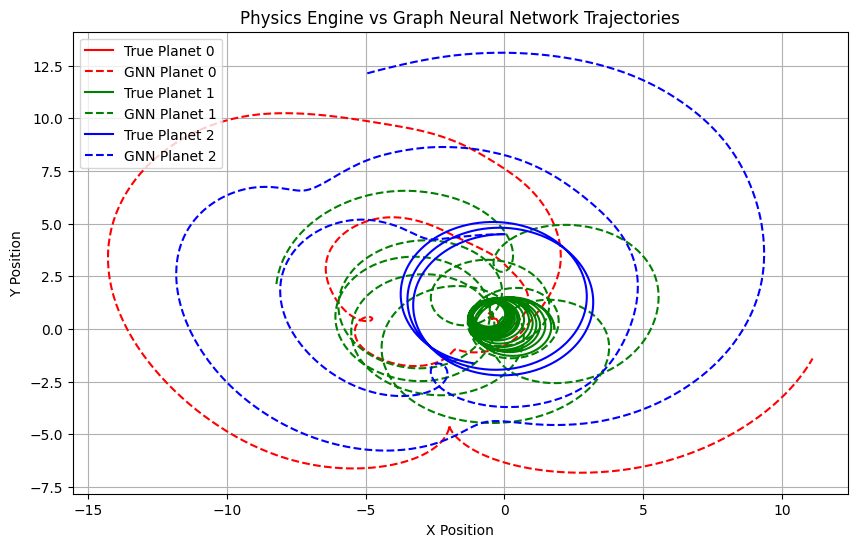

In [ ]:
import matplotlib.pyplot as plt

# 1. Initialize a completely new, unseen starting layout
# Changing positions and masses slightly to see if the GNN generalizes physics
v_state0 = [0.0, 0.0, 0.0, 0.0]     # Star
v_state1 = [1.8, 0.0, 0.0, 6.5]     # Planet 1 (closer, faster)
v_state2 = [0.0, 4.5, -4.0, 0.0]    # Planet 2

new_initial_state = np.concatenate([v_state0, v_state1, v_state2])

# Run ground-truth simulation for the validation set
sol_val = solve_ivp(n_body_derivatives, t_span, new_initial_state, t_eval=t_eval, method='RK45')
val_data = sol_val.y.T.reshape(len(t_eval), 3, 4)

# 2. Let the GNN try to predict the trajectories frame-by-frame (Rollout)
model.eval()
gnn_positions = [val_data[0, :, 0:2]] # Start with the true initial positions
current_features = torch.tensor(val_data[0], dtype=torch.float32).to(device)

dt = 0.01
edge_index = torch.tensor([[0, 0, 1, 1, 2, 2], [1, 2, 0, 2, 0, 1]], dtype=torch.long).to(device)

with torch.no_grad():
    for t in range(len(t_eval) - 1):
        # Predict acceleration using our trained model
        pred_accel = model(current_features, edge_index).cpu().numpy()

        # Physics update (Euler-Maruyama integration step using the AI's predicted acceleration)
        pos = current_features[:, 0:2].cpu().numpy()
        vel = current_features[:, 2:4].cpu().numpy()

        next_vel = vel + pred_accel * dt
        next_pos = pos + next_vel * dt

        gnn_positions.append(next_pos)

        # Update current features for the next step loop
        current_features = torch.tensor(np.hstack([next_pos, next_vel]), dtype=torch.float32).to(device)

gnn_positions = np.array(gnn_positions)

# 3. Plotting Ground Truth vs AI Predictions
plt.figure(figsize=(10, 6))
colors = ['r', 'g', 'b']
for i in range(3):
    # Plot True Trajectories (Solid Lines)
    plt.plot(val_data[:, i, 0], val_data[:, i, 1], label=f'True Planet {i}', color=colors[i], linestyle='-')
    # Plot GNN Predicted Trajectories (Dashed Lines)
    plt.plot(gnn_positions[:, i, 0], gnn_positions[:, i, 1], label=f'GNN Planet {i}', color=colors[i], linestyle='--')

plt.title("Physics Engine vs Graph Neural Network Trajectories")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid(True)
plt.show()